# Runtime

$\newcommand{\ket}[1]{\left|#1\right\rangle} \newcommand{\bra}[1]{\left\langle #1\right|} \newcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle} \newcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}
$This notebook expains how to calculate the queries and runtime of each device. 



In [1]:
# allows us to have visibility on our package without installing it in editing mode
import sys;
if ".." not in sys.path: sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt

## Promise on the annealing schedule

We consider an annealing schedule $\beta_0=0<\beta_1<\cdots<\beta_F$ where $\beta_F$ reaches at most the value $100$. 

For each consecutive pair, we require
$$\left(\sum_x \sqrt{\pi_{\beta_k}(x)\pi_{\beta_{k+1}}(x)}\right)^2 = |\braket{\pi_{\beta_k}}{\pi_{\beta_{k+1}}}|^2 \ge 1/e$$

## Per-platform queries

For the classical walks, the number of queries is the total number of Metropolis proposals executed along the annealing schedule. If $q_t^{\rm loc}(n,\varepsilon)$, $q_t^{\rm unif}(n,\varepsilon)$, and $q_t^{\rm qemc}(n,\varepsilon)$ are the fitted query counts at annealing step $t$, then

* Local proposal: $Q_{\rm loc}(n,\varepsilon)=\sum_t q_t^{\rm loc}(n,\varepsilon)$.
* Uniform proposal: $Q_{\rm unif}(n,\varepsilon)=\sum_t q_t^{\rm unif}(n,\varepsilon)$.
* QEMC proposal: $Q_{\rm qemc}(n,\varepsilon)=\sum_t q_t^{\rm qemc}(n,\varepsilon)$.

For the quantum-walk methods, the query count is the total QSP/QSVT filter degree over the annealing schedule. Given the fitted spectral gap $\delta_t$ at step $t$, the corresponding phase gap is $\Delta_{\theta,t}=\arccos(1-\delta_t)$ and the filter degree is $f_t=2\lceil\ln(1/\varepsilon)/\Delta_{\theta,t}\rceil$. Thus

* Quantum walk with local move: $F_{\rm loc}(n,\varepsilon)=\sum_t 2\lceil\ln(1/\varepsilon)/\arccos(1-\delta_t^{\rm loc})\rceil$.
* Quantum walk with uniform move: $F_{\rm unif}(n,\varepsilon)=\sum_t 2\lceil\ln(1/\varepsilon)/\arccos(1-\delta_t^{\rm unif})\rceil$.
* Quantum walk with QEMC move: $F_{\rm qemc}(n,\varepsilon)=\sum_t 2\lceil\ln(1/\varepsilon)/\arccos(1-\delta_t^{\rm qemc})\rceil$.

Here $Q$ counts classical Metropolis proposals, while $F$ counts calls to the quantum walk or its inverse inside the QSP/QSVT spectral filter.

## Per-platform runtime

For the classical local and uniform walks, the runtime is the number of executed Metropolis steps times a fitted per-step cost. For an annealing schedule with query counts $q_1,\ldots,q_T$, the total number of steps is $Q=\sum_{t=1}^T q_t$.

* Local proposal:
  * CPU: $T_{\rm CPU}^{\rm loc}(n)=Q\left(5.959\cdot10^{-9}+1.429\cdot10^{-10}n\right)$.
  * GPU: $T_{\rm GPU}^{\rm loc}(n)=Q\left(7.837\cdot10^{-7}+1.459\cdot10^{-9}n\right)$.
  * FPGA: $T_{\rm FPGA}^{\rm loc}(n)=Q\left(2.679\cdot10^{-7}+1.800\cdot10^{-9}\log_2 n\right)$.

* Uniform proposal:
  * CPU: $T_{\rm CPU}^{\rm unif}(n)=Q\left(1.173\cdot10^{-8}n+6.964\cdot10^{-11}n^2\right)$.
  * GPU: $T_{\rm GPU}^{\rm unif}(n)=Q\left(2.215\cdot10^{-10}n^2\right)$.
  * FPGA: $T_{\rm FPGA}^{\rm unif}(n)=Q\left(2.541\cdot10^{-7}+4.200\cdot10^{-9}\log_2 n\right)$.

For the classical walk with QEMC move, each Metropolis proposal calls a small quantum circuit. The surface-code distance is chosen from the spacetime volume of one Hamiltonian-simulation query, and the resulting physical time is multiplied by the number of queries.

* QEMC proposal:
  * Logical time per query: $L^{\rm qemc}(n)=1+r(n+2)$, with $r=50$ in the default setting.
  * Logical space per query: $S^{\rm qemc}(n)=n$.
  * Surface-code distance: $d=d_{\rm qemc}(n)$ is the smallest odd integer such that $L^{\rm qemc}(n)S^{\rm qemc}(n)d\,0.1(100p_{\rm phys})^{(d+1)/2}\le 1/3$.
  * Physical time: $T^{\rm qemc}(n)=Q\,L^{\rm qemc}(n)d_{\rm qemc}(n)(4t_{\rm phys}+t_{\rm meas})$.

The quantum walk approach can be implemented either by a sequence of QPE calls or by a sequence of spectral filters via QSP/QSVT. Since we do not need to keep an eigenvalue register, we use the QSP-filter implementation. At annealing step $t$, the filter degree is $f_t=2\lceil\ln(1/\varepsilon)/\Delta_{\theta,t}\rceil$, where $\Delta_{\theta,t}=\arccos(1-\delta_t)$ is the phase gap. We set $F=\sum_t f_t$ and use implementation error $\frac{\varepsilon}{F}$ inside each walk circuit.

* Quantum walk with local move:
  * Logical time for a single local walk: $L_Q^{\rm local}(n,\beta_t,\frac{\varepsilon}{F})$.
  * Logical space for a single local walk: $S_Q^{\rm local}(n,\frac{\varepsilon}{F})$.
  * Surface-code distance for the local move: $d_Q^{\rm local}(n)$ is chosen from the full-walk spacetime volume $V_Q^{\rm local}=\left(\sum_t f_tL_Q^{\rm local}(n,\beta_t,\frac{\varepsilon}{F})\right)S_Q^{\rm local}(n,\frac{\varepsilon}{F})$.
  * Quantum walk with local move: $T_Q^{\rm local}(n)=d_Q^{\rm local}(n)(4t_{\rm phys}+t_{\rm meas})\sum_t f_tL_Q^{\rm local}(n,\beta_t,\frac{\varepsilon}{F})$.

* Quantum walk with uniform move:
  * Logical time for a single uniform walk: $L_Q^{\rm uniform}(n,\beta_t,\frac{\varepsilon}{F})$.
  * Logical space for a single uniform walk: $S_Q^{\rm uniform}(n,\frac{\varepsilon}{F})$.
  * Surface-code distance for the uniform move: $d_Q^{\rm uniform}(n)$ is chosen from the full-walk spacetime volume $V_Q^{\rm uniform}=\left(\sum_t f_tL_Q^{\rm uniform}(n,\beta_t,\frac{\varepsilon}{F})\right)S_Q^{\rm uniform}(n,\frac{\varepsilon}{F})$.
  * Quantum walk with uniform move: $T_Q^{\rm uniform}(n)=d_Q^{\rm uniform}(n)(4t_{\rm phys}+t_{\rm meas})\sum_t f_tL_Q^{\rm uniform}(n,\beta_t,\frac{\varepsilon}{F})$.

* Quantum walk with QEMC move:
  * Logical time for a single QEMC walk: $L_Q^{\rm qemc}(n,\beta_t,\frac{\varepsilon}{F})$.
  * Logical space for a single QEMC walk: $S_Q^{\rm qemc}(n,\frac{\varepsilon}{F})$.
  * Surface-code distance for the QEMC move: $d_Q^{\rm qemc}(n)$ is chosen from the full-walk spacetime volume $V_Q^{\rm qemc}=\left(\sum_t f_tL_Q^{\rm qemc}(n,\beta_t,\frac{\varepsilon}{F})\right)S_Q^{\rm qemc}(n,\frac{\varepsilon}{F})$.
  * Quantum walk with QEMC move: $T_Q^{\rm qemc}(n)=d_Q^{\rm qemc}(n)(4t_{\rm phys}+t_{\rm meas})\sum_t f_tL_Q^{\rm qemc}(n,\beta_t,\frac{\varepsilon}{F})$.


## Annealing schedule

### Worst-case, loose bounds on the annealing schedule

[Wocjan and Abeyesinghe, Section V](https://arxiv.org/pdf/0804.4259) gives a worst-case annealing-step rule for Boltzmann-Gibbs states. For a classical Hamiltonian $H$ with energies $E(x)\ge0$, the coherent Gibbs states satisfy 
$$|\braket{\pi_\beta}{\pi_{\beta+\Delta\beta}}|^2\ge \exp(-\|H\|\Delta\beta)$$ 
for all $\beta$ and all $\Delta\beta$. Here $\| H \|$ is the operator norm. 

Therefore, choosing $\Delta\beta=1/\|H\|$ guarantees $|\braket{\pi_\beta}{\pi_{\beta+\Delta\beta}}|^2 \ge 1/e$. In the worst case, reaching inverse temperature $\beta$ requires $r=\beta\|H\|$ annealing steps, with $\beta_i=i/\|H\|$ for $i=0,\ldots,r$.

For the SK model we have that $\|H\| \approx 2n$ (shown numerically in notebook 0_data.ipynb).

In [2]:
def worst_case_annealing(n: int, beta: float) -> list[float]:
    step = 1.0 / (2.0 * n)
    num_steps = int(np.ceil(beta / step))
    return list(np.linspace(0.0, beta, num_steps + 1)[1:])

### Tight bounds on the annealing schedule

We developed an improved approach, presented in the notebook `4.1_heuristic_scheduling.ipynb`, which gives

$$
\Delta\beta(n, \beta) = \frac{2}{\sqrt{n v(\beta)}} = \frac{1}{\sqrt{n}}
\begin{cases}
\exp\left(-0.111\,\beta + 0.615\,\beta^2\right), & \beta<1,\\[3mm]
0.533\,(\beta+0.286)^{7/4}, & \beta\geq1.
\end{cases}
$$

The query plot is the following:

In [3]:
from monaqa2.data.plot_main3 import plot_annealing_classical_queries_and_quantum_queries_vs_n

In [4]:
from monaqa2.data.plot_main3 import plot_annealing_classical_queries_and_quantum_runtime_vs_n

3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 n=np.int64(100) classical_runtime=[np.float64(1.3866958376268705), np.float64(2.825990556169044), np.float64(5.657195658469015), np.float64(11.16939422841199), np.float64(21.83767224889129), np.float64(42.42260596390353), np.float64(82.11177978818044), np.float64(158.71916496218762), np.float64(306.9817047554273), np.float64(595.0814367818084), np.float64(1157.8198854184204), np.float64(2263.7849172168744), np.float64(4452.46930401402), np.float64(8816.459323719313), np.float64(17586.690390587682), np.float64(35355.189806666036), np.float64(71647.24689923685), np.float64(146366.60958544296), np.float64(301389.75268421485), np.float64(625383.2872265313), np.float64(1307177.6793216597), np.float64(2751044

(<Figure size 850x480 with 1 Axes>,
 <Axes: title={'center': 'Annealing runtime, $\\beta_F=4.0$, $\\epsilon=0.01$'}, xlabel='$n$', ylabel='Runtime [s]'>)

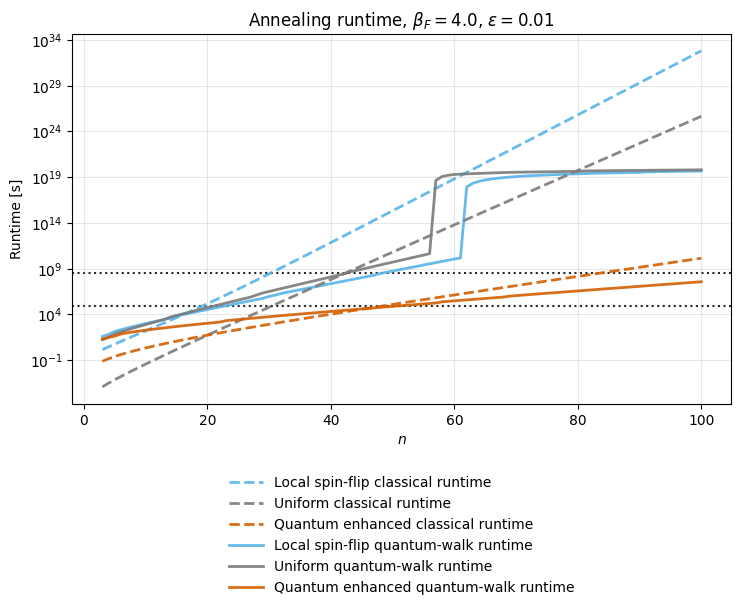

In [5]:
plot_annealing_classical_queries_and_quantum_runtime_vs_n(
    beta=4.0, epsilon=1e-2, annealing_schedule_generator=worst_case_annealing,
    n_plot_min=3, n_plot_max=100)

3 4 5 6 7 8 9 10 n=np.int64(10) classical_queries=[5121640.0, 10408820.0, 20792458.0, 40980665.0, 80005209.0, 155223612.0, 300109753.0, 579521992.0] quantum_queries=[1024, 1702, 2650, 3980, 5814, 8356, 11860, 16664]
3 4 5 6 7 8 9 10 n=np.int64(10) classical_queries=[475.0, 1168.0, 2737.0, 6198.0, 13726.0, 29910.0, 64324.0, 136960.0] quantum_queries=[494, 882, 1474, 2374, 3732, 5764, 8800, 13272]
3 4 5 6 7 8 9 10 n=np.int64(10) classical_queries=[722.0, 1145.0, 1716.0, 2460.0, 3443.0, 4730.0, 6403.0, 8577.0] quantum_queries=[562, 804, 1122, 1444, 1854, 2322, 2848, 3442]


(<Figure size 850x480 with 1 Axes>,
 <Axes: title={'center': 'Annealing queries, $\\beta_F=4.0$, $\\epsilon=0.01$'}, xlabel='$n$', ylabel='Queries'>)

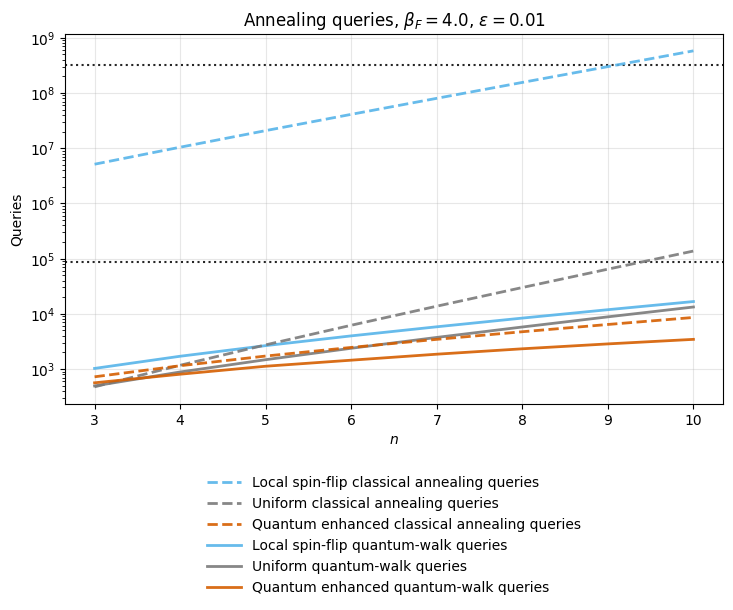

In [11]:
plot_annealing_classical_queries_and_quantum_queries_vs_n(
    beta=4.0, epsilon=1e-2, annealing_schedule_generator=worst_case_annealing,
    n_plot_min=3, n_plot_max=10)

## Heuristic choice of the annealing step

